In [1]:
!pip install -q google-cloud-storage opencv-python numpy matplotlib

print("✓ Dependencies installed")


✓ Dependencies installed


In [2]:
import numpy as np
import cv2
import gzip
import json
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Generator, Tuple, List

from google.cloud import storage
from google.auth.credentials import AnonymousCredentials

print("✓ Imports ready")


✓ Imports ready


In [30]:
@dataclass
class Frame:
    frame_id: int
    timestamp: float
    rgb: np.ndarray
    depth: np.ndarray
    session_id: str
    camera: str
    view: str
    fps: int
    resolution: Tuple[int, int]


class SANPOLoader:
    def __init__(self,
                 sanpo_root="gs://gresearch/sanpo_dataset/v0/sanpo-real",
                 camera="chest",
                 view="left"):

        self.sanpo_root = sanpo_root.rstrip("/")
        self.camera = camera
        self.view = view

        # GCS setup (public bucket)
        credentials = AnonymousCredentials()
        self.client = storage.Client(credentials=credentials, project='gresearch')

        parts = self.sanpo_root.split("/")
        self.bucket_name = parts[2]
        self.prefix = "/".join(parts[3:])

        self.bucket = self.client.bucket(self.bucket_name)

    def list_sessions(self):
      prefix = f"{self.prefix}/"
      blobs = self.bucket.list_blobs(prefix=prefix)

      sessions = set()

      for blob in blobs:
          parts = blob.name[len(prefix):].split("/")
          if len(parts) > 1:
              sessions.add(parts[0])  # first folder = session_id

      sessions = sorted(list(sessions))
      return sessions

    def get_session_metadata(self, session_id):
        path = f"{self.prefix}/{session_id}/description.json"
        blob = self.bucket.blob(path)
        return json.loads(blob.download_as_string())

    def _get_rgb(self, session_id, frame_id):
        candidates = [
          f"{self.prefix}/{session_id}/camera_{self.camera}/{self.view}/video_frames/{frame_id:06d}.png",
          f"{self.prefix}/{session_id}/camera_{self.camera}/video_frames/{self.view}/{frame_id:06d}.png",
          f"{self.prefix}/{session_id}/camera_{self.camera}/{self.view}/rgb/{frame_id:06d}.png",
      ]

        for path in candidates:
          blob = self.bucket.blob(path)
          if blob.exists():
              try:
                  arr = np.frombuffer(blob.download_as_bytes(), np.uint8)
                  img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
                  return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
              except:
                  continue

        return None


    def _get_depth(self, session_id, frame_id):
      path = f"{self.prefix}/{session_id}/camera_{self.camera}/{self.view}/depth_maps/{frame_id:06d}.float16.gz"
      blob = self.bucket.blob(path)

      try:
          raw = gzip.decompress(blob.download_as_bytes())
          depth = np.frombuffer(raw, dtype=np.float16)

          print("Before trim:", len(depth))

          expected = 720 * 1280

          if len(depth) > expected:
              depth = depth[:expected]

          print("After trim:", len(depth))

          if len(depth) != expected:
              print("❌ Still wrong size")
              return None

          depth = depth.reshape(720, 1280)
          return depth.astype(np.float32)

      except Exception as e:
          print(f"Depth load error: {e}")
          return None

    def iter_frames(self, session_id, max_frames=5):
        meta = self.get_session_metadata(session_id)
        fps = meta.get("fps", 15)

        for i in range(max_frames):
            rgb = self._get_rgb(session_id, i)
            depth = self._get_depth(session_id, i)

            if rgb is None or depth is None:
                break

            yield Frame(
                frame_id=i,
                timestamp=i/fps,
                rgb=rgb,
                depth=depth,
                session_id=session_id,
                camera=self.camera,
                view=self.view,
                fps=fps,
                resolution=(rgb.shape[1], rgb.shape[0])
            )

print("✓ Loader defined")


✓ Loader defined


In [31]:
loader = SANPOLoader()
print("✓ Loader initialized")


✓ Loader initialized


In [37]:
loader = SANPOLoader()

sessions = loader.list_sessions()
session_id = sessions[0]

frames = list(loader.iter_frames(session_id, max_frames=5))

print("Frames loaded:", len(frames))


Before trim: 921602
After trim: 921600
Before trim: 921602
After trim: 921600
Before trim: 921602
After trim: 921600
Before trim: 921602
After trim: 921600
Before trim: 921602
After trim: 921600
Frames loaded: 5


In [38]:
sessions = loader.list_sessions()

assert len(sessions) > 0, "❌ No sessions found!"

print(f"✓ Found {len(sessions)} sessions")
print("Sample sessions:", sessions[:5])


✓ Found 702 sessions
Sample sessions: ['-5OCPnbrwJdu3jH70ieU7pUiFsOJQoeG', '-F9N8JhMuJZmOpz2M8o1At2j-jAas9AA', '-MnIHGYpsPvn4CF_iAKGfRQewKSEZGv1', '-PXxwecxoR8mWhFQ09j-lddcSMLO_0K2', '-PqSDmiEe2pXjmYHgxh4YEBsj0T5LU10']


In [39]:
session_id = sessions[0]

meta = loader.get_session_metadata(session_id)

print("✓ Metadata loaded:")
print(json.dumps(meta, indent=2)[:500])


✓ Metadata loaded:
{
  "session_type": "real",
  "session_video_metadata": {
    "human_traffic": "HUMAN_TRAFFIC_MODERATE",
    "vehicular_traffic": "VEHICULAR_TRAFFIC_HEAVY",
    "animal_traffic": "ANIMAL_TRAFFIC_LOW",
    "num_obstacles": "NUM_OBSTACLES_MEDIUM",
    "environment_types": [
      "ENVIRONMENT_TYPE_URBAN",
      "ENVIRONMENT_TYPE_ROAD_JUNCTION"
    ],
    "weather_conditions": [
      "WEATHER_CONDITION_SUNNY"
    ],
    "visibility": "VISIBILITY_HIGH",
    "ego_motion": "EGO_MOTION_WALKING",
    "


In [41]:
frames = list(loader.iter_frames(session_id, max_frames=5))

assert len(frames) > 0, "❌ No frames loaded!"

print(f"✓ Loaded {len(frames)} frames")


Before trim: 921602
After trim: 921600
Before trim: 921602
After trim: 921600
Before trim: 921602
After trim: 921600
Before trim: 921602
After trim: 921600
Before trim: 921602
After trim: 921600
✓ Loaded 5 frames


In [42]:
for i, f in enumerate(frames):
    assert f.rgb.shape[2] == 3
    assert len(f.depth.shape) == 2

    print(f"Frame {i}: RGB {f.rgb.shape}, Depth {f.depth.shape}, "
          f"Range [{f.depth.min():.2f}, {f.depth.max():.2f}] m")


Frame 0: RGB (1242, 2208, 3), Depth (720, 1280), Range [0.54, 1280.00] m
Frame 1: RGB (1242, 2208, 3), Depth (720, 1280), Range [0.54, 1280.00] m
Frame 2: RGB (1242, 2208, 3), Depth (720, 1280), Range [0.54, 1280.00] m
Frame 3: RGB (1242, 2208, 3), Depth (720, 1280), Range [0.54, 1280.00] m
Frame 4: RGB (1242, 2208, 3), Depth (720, 1280), Range [0.54, 1280.00] m


In [44]:
all_depths = np.concatenate([f.depth.flatten() for f in frames])

print("Min:", np.min(all_depths))
print("Max:", np.max(all_depths))
print("Mean:", np.mean(all_depths))

valid_depths = all_depths[all_depths < 100]

assert len(valid_depths) > 0, "No valid depth values"
assert np.min(valid_depths) >= 0
assert np.max(valid_depths) < 50   # realistic range

assert np.min(all_depths) >= 0

print("✓ Depth values valid")


Min: 0.5361328
Max: 1280.0
Mean: 3.399428
✓ Depth values valid


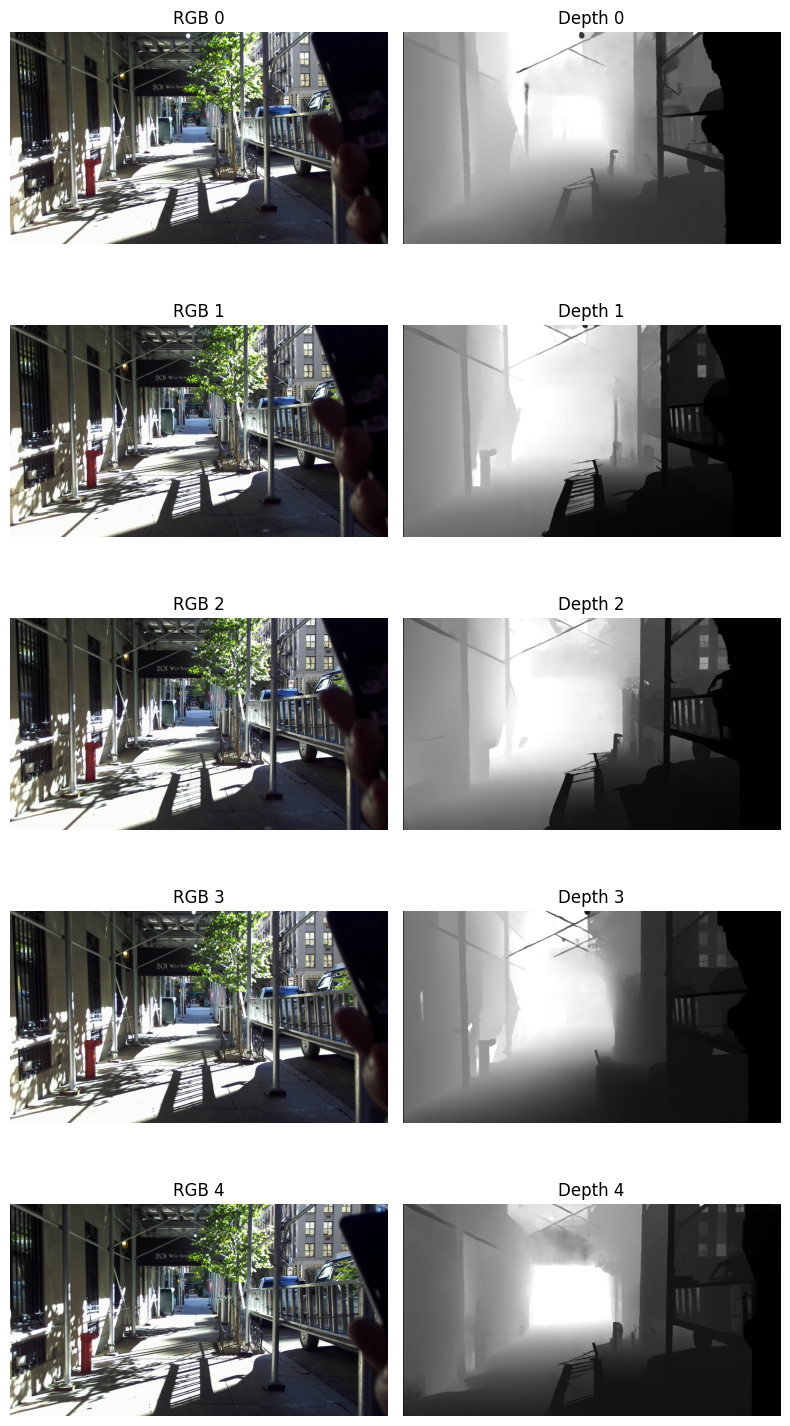

In [45]:
fig, axes = plt.subplots(len(frames), 2, figsize=(8, 3*len(frames)))

for i, f in enumerate(frames):
    axes[i, 0].imshow(f.rgb)
    axes[i, 0].set_title(f"RGB {i}")
    axes[i, 0].axis("off")

    depth_vis = np.clip(f.depth, 0, np.percentile(f.depth, 95))
    axes[i, 1].imshow(depth_vis, cmap='gray')
    axes[i, 1].set_title(f"Depth {i}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()
